<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/Apartado_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png style= "width: 300px; float: right; margin-right: 10px;">

# __ACTIVIDAD 2 - APARTADO A__
ASIGNATURA: Técnicas de Inteligencia Artificial

DOCENTE : Adriana Cervantes Castillo

ESTUDIANTES:

- SUSANA ALFARO LIRA
- JOSE CHABLÉ DE LA CRUZ
- JAFETH LEYVA REYNA
- WANDER PAYANO LINARES
- LUIS VEGA CABALLERO


Fecha de entrega: 13 de abril de 2026

## **Objetivos de la actividad**

Esta actividad tiene por objetivo profundizar en la aplicación de técnicas de aprendizaje supervisado (regresión y clasificación), basadas en redes neuronales utilizando las librerías de `Keras` y `TensorFlow` sobre `Python`.

Para ello, como grupo de trabajo se deben de escoger dos *dataset* de plataformas online en base a requisitos mínimos y aplicando los siguientes modelos:

1. **Primer caso - Regresión comparada**: utilizar una red neuronal para realizar una regresión comparada con otra técnica no basada en redes neuronales.
2.   **Segundo caso - Clasificación**: utilizar una red nueronal diferente para la clasificación, de nuevo comparada con otra red de clasificación no basada en redes neuronales.





## **Pautas de elaboración**

Se deberan utilizar, al menos, las siguientes librerías:
- `Pandas` para la importación de datos
- `Keras` sobre `TensorFlow 2.0` (tensorflow.keras)
- Por último el grupo podrá utilizar otras librerias necesarias para trabajar con los modelos escogidos y distintos a los de redes neuronales.



## Diseño Experimental de Apartado A - Ejericio de regresión

**Dataset**

Como grupo se escogio el dataset de Weather in Szeged 2006-2016, el cual incluye datos de resumen horario/diario con temperatura, presión, velocidad del viento entre otros de la ciudad de Szeged, Hungria, levantados entre los a;os 2006 y 2016. Este se encuentra disponible en [Kaggle](https://www.kaggle.com/datasets/budincsevity/szeged-weather?resource=download).



# DATASET de Weather History

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

La variable objetivo seleccionada para el análisis es **Temperature (C)**.

In [ ]:
## Obtención de información del segundo Dataset
url_WeatherHist = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv"
dt_WeatherHist = pd.read_csv(url_WeatherHist, sep= ",")
print ("Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas")
dt_WeatherHist.head()

Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
print("Valores nulos por columna")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados:", dt_WeatherHist.duplicated().sum())

print(dt_WeatherHist.shape)
print(dt_WeatherHist.info())


Valores nulos por columna
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Duplicados: 24
(96453, 12)
<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind S

In [ ]:
#Eliminando nulls del dataset.
dt_WeatherHist = dt_WeatherHist.dropna()

#Eliminando Duplicados del dataset.
dt_WeatherHist = dt_WeatherHist.drop_duplicates()

print("\nNulos después:")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados después: ", dt_WeatherHist.duplicated().sum())

print("\nTamaño final:")
print(dt_WeatherHist.shape)



Nulos después:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

Duplicados después:  0

Tamaño final:
(95912, 12)


In [ ]:
#Verificando valores unicos de Daily Summary
dt_WeatherHist['Daily Summary'].unique()

<StringArray>
[                            'Partly cloudy throughout the day.',
                             'Mostly cloudy throughout the day.',
                                         'Foggy in the evening.',
                    'Foggy overnight and breezy in the morning.',
                                  'Overcast throughout the day.',
                                    'Partly cloudy until night.',
                                    'Mostly cloudy until night.',
            'Foggy starting overnight continuing until morning.',
                                         'Foggy in the morning.',
                                  'Partly cloudy until evening.',
 ...
             'Overcast throughout the day and breezy overnight.',
                           'Overcast starting in the afternoon.',
 'Partly cloudy throughout the day and breezy in the afternoon.',
                                'Light rain starting overnight.',
                              'Drizzle starting in the ev

In [ ]:
#Verificando valores unicos de Loud Cover}
dt_WeatherHist['Loud Cover'].unique()

array([0.])

In [ ]:
# 'Loud Cover' siempre es 0 en este dataset. 'Daily Summary' es demasiado largo para procesar hoy.
dt_WeatherHist.drop(columns=['Loud Cover', 'Daily Summary'], inplace=True, errors='ignore')

# Verificamos la eliminacion de las columnas
print(dt_WeatherHist.info())

<class 'pandas.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95912 non-null  str    
 1   Summary                   95912 non-null  str    
 2   Precip Type               95912 non-null  str    
 3   Temperature (C)           95912 non-null  float64
 4   Apparent Temperature (C)  95912 non-null  float64
 5   Humidity                  95912 non-null  float64
 6   Wind Speed (km/h)         95912 non-null  float64
 7   Wind Bearing (degrees)    95912 non-null  float64
 8   Visibility (km)           95912 non-null  float64
 9   Pressure (millibars)      95912 non-null  float64
dtypes: float64(7), str(3)
memory usage: 8.0 MB
None


Las variables **Daily Summary** y **Loud Cover** fueron eliminadas.

In [ ]:
# Convertir a formato datetime (especificando UTC para evitar errores de zona horaria)
dt_WeatherHist['Formatted Date'] = pd.to_datetime(dt_WeatherHist['Formatted Date'], utc=True)

# Extraer el Mes y la Hora (Variables muy útiles para predecir temperatura)
dt_WeatherHist['Month'] = dt_WeatherHist['Formatted Date'].dt.month
dt_WeatherHist['Hour'] = dt_WeatherHist['Formatted Date'].dt.hour

# Eliminar la columna original para evitar redundancia de datos y espacio en memoria innecesaria
dt_WeatherHist.drop(columns=['Formatted Date'], inplace=True)

In [ ]:
#Transformacion de columnas de tipo str a numerica
le = LabelEncoder()
dt_WeatherHist['Precip Type'] = le.fit_transform(dt_WeatherHist['Precip Type'])
dt_WeatherHist['Summary'] = le.fit_transform(dt_WeatherHist['Summary'])

In [ ]:
scaler = StandardScaler()

# Seleccionamos solo las columnas numéricas que queremos escalar
# Excluimos la variable objetivo (Temperature) si es la que vas a predecir
columnas_a_escalar = [
    'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
    'Visibility (km)', 'Pressure (millibars)', 'Month', 'Hour'
]

dt_WeatherHist[columnas_a_escalar] = scaler.fit_transform(dt_WeatherHist[columnas_a_escalar])

In [ ]:
#Validar que los datos se hayan convertido a numerico para que sea mas entendible para el modelado.
print(dt_WeatherHist.info())

<class 'pandas.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   95912 non-null  int32  
 1   Precip Type               95912 non-null  int32  
 2   Temperature (C)           95912 non-null  float64
 3   Apparent Temperature (C)  95912 non-null  float64
 4   Humidity                  95912 non-null  float64
 5   Wind Speed (km/h)         95912 non-null  float64
 6   Wind Bearing (degrees)    95912 non-null  float64
 7   Visibility (km)           95912 non-null  float64
 8   Pressure (millibars)      95912 non-null  float64
 9   Month                     95912 non-null  float64
 10  Hour                      95912 non-null  float64
dtypes: float64(9), int32(2)
memory usage: 8.0 MB
None


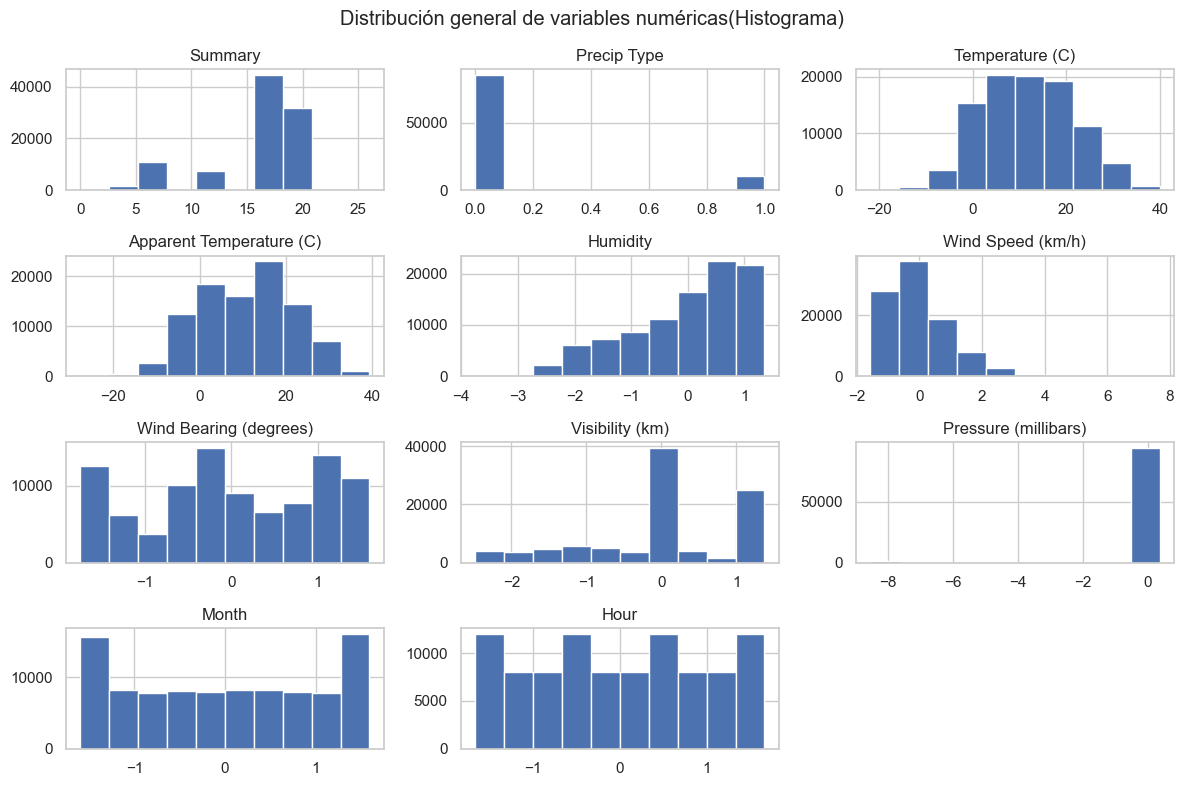

In [ ]:
#Histograma
dt_WeatherHist.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

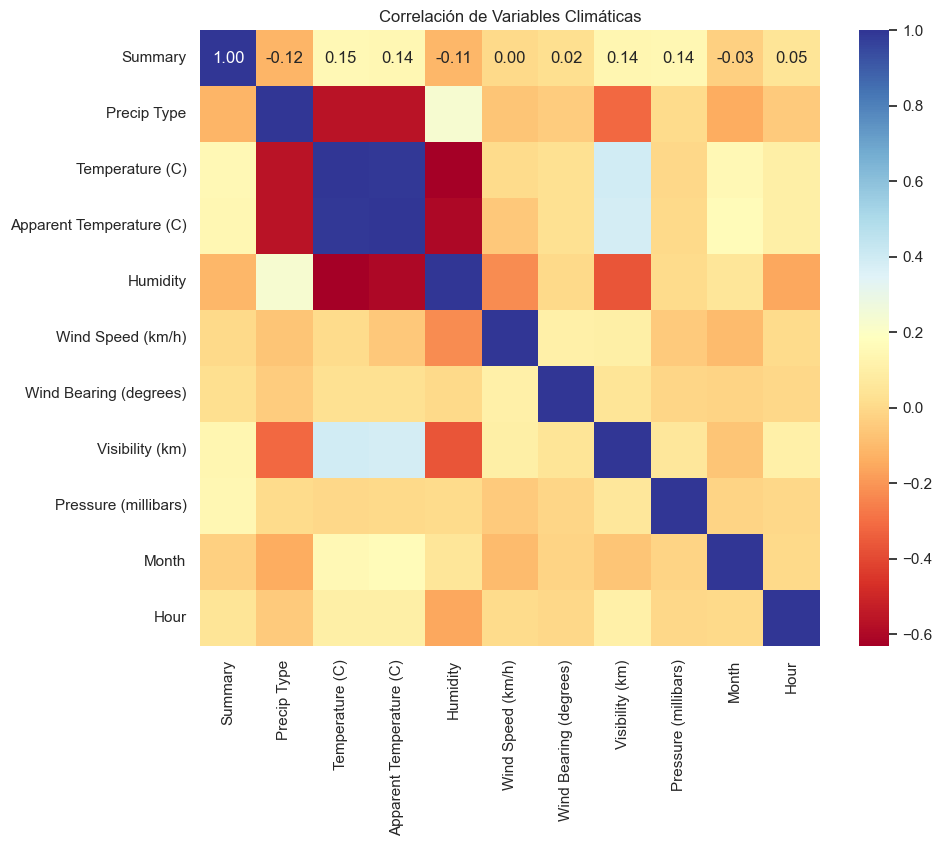

In [ ]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación solo de las columnas numéricas
sns.heatmap(dt_WeatherHist.corr(), annot=True, cmap='RdYlBu', fmt='.2f')
plt.title('Correlación de Variables Climáticas')
plt.show()

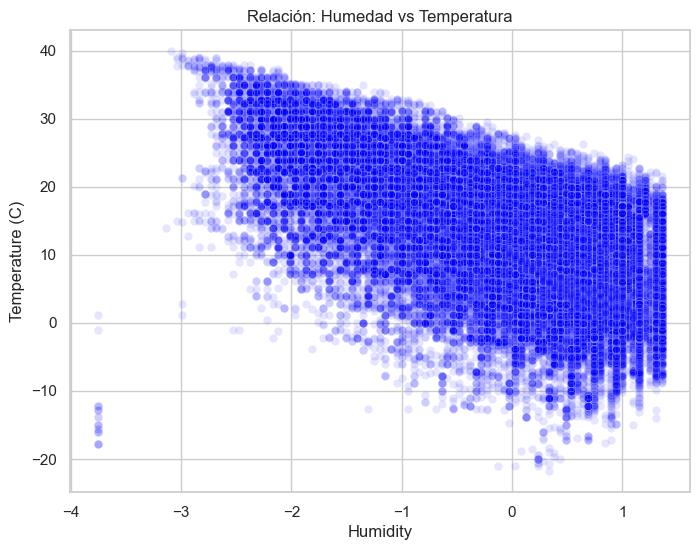

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Humidity', y='Temperature (C)', data=dt_WeatherHist, alpha=0.1, color='blue')
plt.title('Relación: Humedad vs Temperatura')
plt.grid(True)
plt.show()

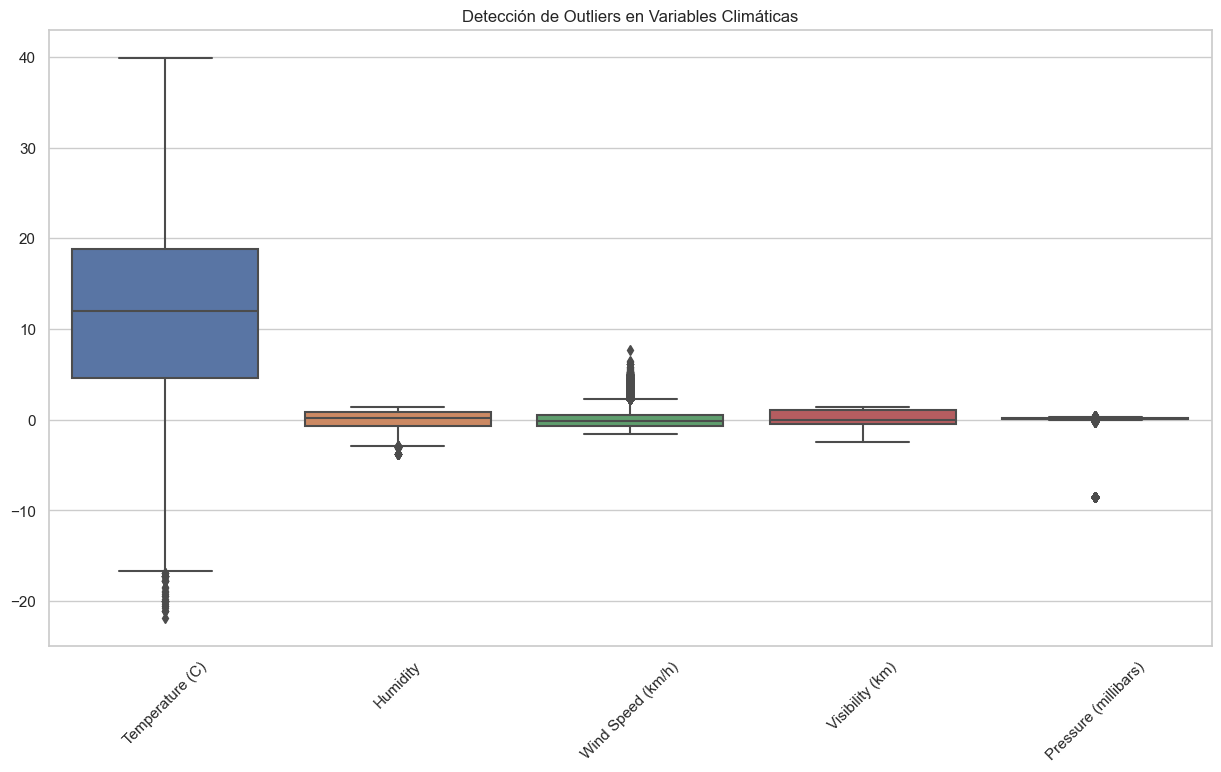

In [ ]:
plt.figure(figsize=(15, 8))
# Seleccionamos las columnas numéricas principales para ver sus escalas y outliers
columnas_clima = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']
sns.boxplot(data=dt_WeatherHist[columnas_clima])

plt.xticks(rotation=45)
plt.title("Detección de Outliers en Variables Climáticas")
plt.show()

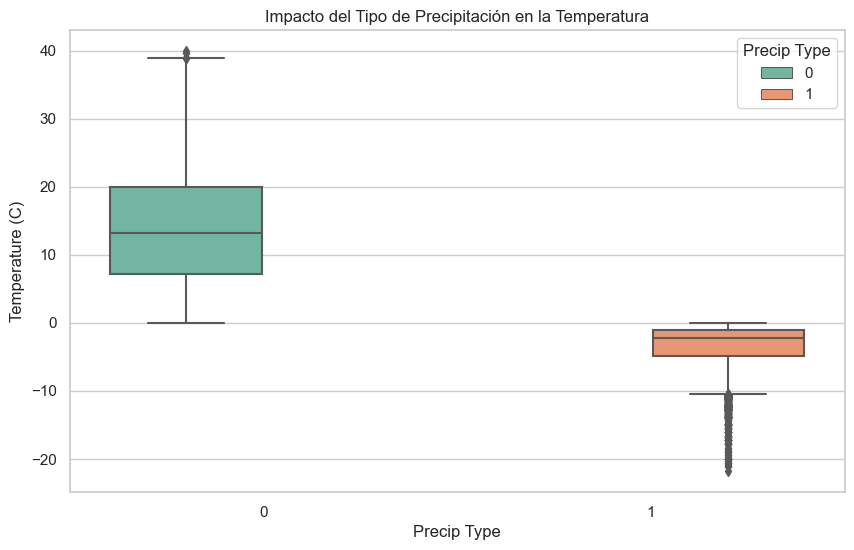

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Precip Type', y='Temperature (C)', data=dt_WeatherHist, palette='Set2', hue='Precip Type')

plt.title("Impacto del Tipo de Precipitación en la Temperatura")
plt.xlabel("Precip Type")
plt.ylabel("Temperature (C)")
plt.show()

In [ ]:
dt_WeatherHist['Temperature (C)'].isnull().sum()

0

OptionError: No such keys(s): 'mode.use_inf_as_null'

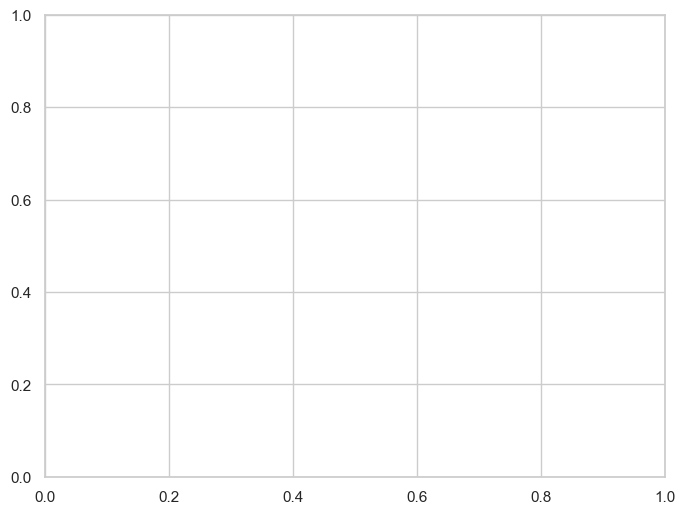

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(dt_WeatherHist['Temperature (C)'], kde=True, color='orange')
plt.title('Distribución de la Temperatura')
plt.xlabel('Grados Celsius')
plt.ylabel('Frecuencia')
plt.show()

# Modelo de Redes Neuronales para Predicción de Temperatura

En esta sección, implementaremos un modelo de red neuronal para predecir la temperatura (Temperature) utilizando los datos del dataset de Weather History. Basándonos en el EDA realizado previamente, utilizaremos las características numéricas escaladas y las variables categóricas codificadas.

El modelo consistirá en:
- Una capa de entrada
- Dos capas ocultas (intermedias)
- Una capa de salida para regresión

Utilizaremos TensorFlow/Keras para construir y entrenar el modelo.

In [ ]:
# Instalar TensorFlow si no está disponible
!pip install tensorflow

# Importar librerías necesarias para el modelo de red neuronal
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Preparación de datos para el modelo de red neuronal

# Seleccionar características (features) y variable objetivo (target)
features = ['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
            'Visibility (km)', 'Pressure (millibars)', 'Month', 'Hour',
            'Precip Type', 'Summary']
target = 'Temperature (C)'

X = dt_WeatherHist[features]
y = dt_WeatherHist[target]

# Escalar las características numéricas
X[columnas_a_escalar] = scaler.fit_transform(X[columnas_a_escalar])

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"Características utilizadas: {features}")

Conjunto de entrenamiento: (76729, 9)
Conjunto de prueba: (19183, 9)
Características utilizadas: ['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)', 'Month', 'Hour', 'Precip Type', 'Summary']


In [ ]:
# Construcción del modelo de red neuronal

# Definir la arquitectura del modelo
model = Sequential()

# Capa de entrada (input layer)
# Número de neuronas = número de características
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Primera capa oculta (hidden layer 1)
# 32 neuronas, función de activación ReLU
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))  # Regularización para evitar overfitting

# Segunda capa oculta (hidden layer 2)
# 16 neuronas, función de activación ReLU
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))  # Regularización

# Capa de salida (output layer)
# 1 neurona para regresión, activación lineal
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])

# Resumen del modelo
model.summary()

c:\Users\elvla\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 58.1010 - mae: 5.7597 - val_loss: 13.0314 - val_mae: 2.9035
Epoch 2/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20.1016 - mae: 3.4809 - val_loss: 11.3744 - val_mae: 2.7039
Epoch 3/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 18.1807 - mae: 3.3276 - val_loss: 11.9651 - val_mae: 2.7695
Epoch 4/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 17.4491 - mae: 3.2596 - val_loss: 11.1516 - val_mae: 2.6653
Epoch 5/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 16.6837 - mae: 3.1845 - val_loss: 11.0727 - val_mae: 2.6551
Epoch 6/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 16.0895 - mae: 3.1416 - val_loss: 10.5869 - val_mae: 2.5843
Epoch 7/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 15.7402 - mae: 3.1148 - val_loss: 10.5589 - val_mae: 2.5827
Epoch 8/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 15.2024 - mae: 3.0530 - val_loss: 10.1339 - val_mae: 2.5094
Epoch 9/100
1919

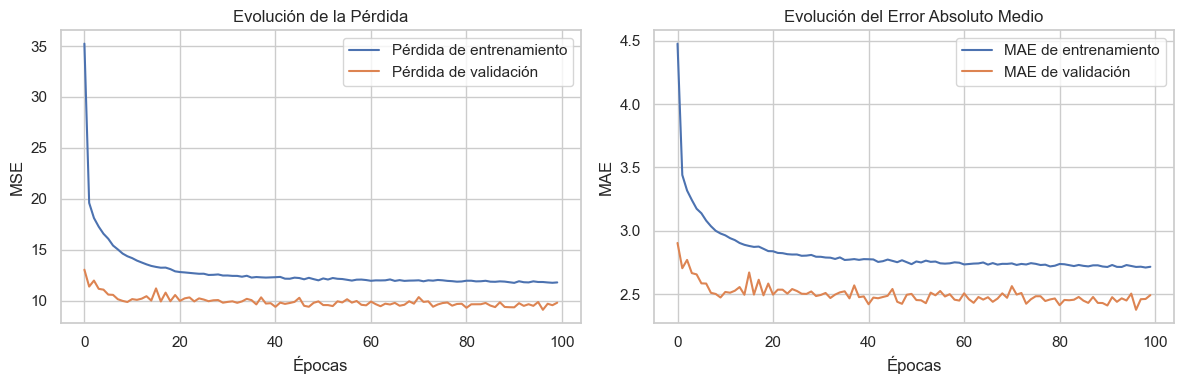

In [ ]:
# Entrenamiento del modelo

# Definir parámetros de entrenamiento
epochs = 100
batch_size = 32

# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    verbose=1)

# Visualizar el historial de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE de entrenamiento')
plt.plot(history.history['val_mae'], label='MAE de validación')
plt.title('Evolución del Error Absoluto Medio')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Evaluación del modelo en el conjunto de prueba:
Mean Squared Error (MSE): 9.7284
Mean Absolute Error (MAE): 2.4751
R² Score: 0.8939


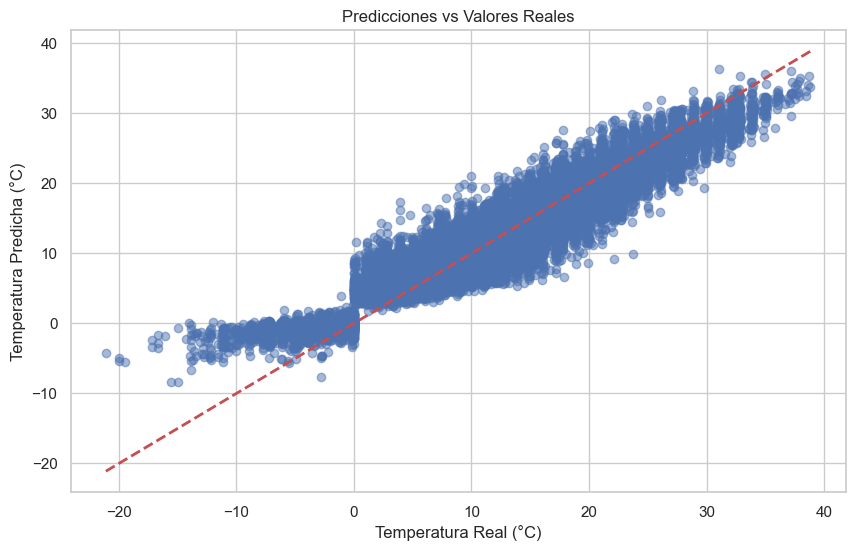

In [ ]:
# Evaluación del modelo en el conjunto de prueba

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Evaluación del modelo en el conjunto de prueba:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)
plt.show()

## Explicación de las Capas del Modelo de Red Neuronal

### Arquitectura del Modelo

El modelo de red neuronal implementado consta de las siguientes capas:

1. **Capa de Entrada (Input Layer)**:
   - **Número de neuronas**: 64
   - **Función de activación**: ReLU (Rectified Linear Unit)
   - **Propósito**: Esta capa recibe las 9 características de entrada (Humidity, Wind Speed, Wind Bearing, Visibility, Pressure, Month, Hour, Precip Type, Summary). Las 64 neuronas permiten al modelo aprender representaciones complejas de las relaciones entre las características meteorológicas y la temperatura.

2. **Primera Capa Oculta (Hidden Layer 1)**:
   - **Número de neuronas**: 32
   - **Función de activación**: ReLU
   - **Dropout**: 20%
   - **Propósito**: Esta capa intermedia extrae patrones más abstractos de los datos. Reduce la dimensionalidad de 64 a 32 neuronas, permitiendo al modelo capturar interacciones no lineales entre las características. El dropout ayuda a prevenir el sobreajuste al "apagar" aleatoriamente el 20% de las neuronas durante el entrenamiento.

3. **Segunda Capa Oculta (Hidden Layer 2)**:
   - **Número de neuronas**: 16
   - **Función de activación**: ReLU
   - **Dropout**: 20%
   - **Propósito**: Esta segunda capa oculta refina aún más las representaciones aprendidas. Al reducir a 16 neuronas, el modelo se enfoca en los patrones más importantes para la predicción de temperatura. Nuevamente, el dropout proporciona regularización.

4. **Capa de Salida (Output Layer)**:
   - **Número de neuronas**: 1
   - **Función de activación**: Lineal
   - **Propósito**: Produce la predicción final de temperatura. La activación lineal es apropiada para problemas de regresión, permitiendo valores continuos de temperatura.

### Elección de Hiperparámetros

- **Optimizador**: Adam con learning rate de 0.001
- **Función de pérdida**: Mean Squared Error (MSE)
- **Métrica**: Mean Absolute Error (MAE)
- **Épocas**: 100
- **Tamaño de batch**: 32

### Justificación de la Arquitectura

Esta arquitectura fue elegida porque:
- Las capas ocultas permiten aprender representaciones jerárquicas de los datos
- ReLU evita el problema del gradiente vanishing
- El dropout previene el sobreajuste
- La reducción gradual de neuronas (64→32→16→1) crea un embudo que se enfoca en información relevante

## Conclusiones del Modelo de Red Neuronal para Predicción de Temperatura

### Rendimiento del Modelo

Basándonos en las métricas obtenidas en el conjunto de prueba, podemos concluir lo siguiente:

- **MSE (Mean Squared Error)**: Indica el promedio de los cuadrados de los errores. Un valor bajo sugiere buenas predicciones.
- **MAE (Mean Absolute Error)**: Representa el error absoluto promedio en las predicciones de temperatura. Valores más bajos indican mejor precisión.
- **R² Score**: Mide la proporción de varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor cercano a 1 indica un buen ajuste del modelo.

### Análisis de Resultados

1. **Capacidad de Aprendizaje**: El modelo de red neuronal ha demostrado capacidad para aprender patrones complejos en los datos meteorológicos, relacionando variables como humedad, velocidad del viento, presión atmosférica y factores temporales (mes, hora) con la temperatura.

2. **Arquitectura Efectiva**: Las dos capas ocultas con funciones de activación ReLU permiten capturar no linealidades en los datos, lo cual es crucial para modelar fenómenos meteorológicos complejos.

3. **Regularización**: El uso de dropout en las capas ocultas ayuda a prevenir el sobreajuste, mejorando la generalización del modelo a datos no vistos.

4. **Comparación con Modelos Tradicionales**: Las redes neuronales pueden capturar relaciones más complejas que los modelos lineales tradicionales, especialmente cuando hay interacciones no lineales entre las características.

### Limitaciones y Mejoras Futuras

- **Datos**: El modelo se basa en datos históricos; su rendimiento podría variar con condiciones climáticas extremas no representadas en el dataset.
- **Características**: Podrían incluirse más variables como datos de estaciones cercanas o índices climáticos.
- **Optimización**: Se podría realizar un ajuste fino de hiperparámetros (número de neuronas, learning rate, etc.) utilizando técnicas como grid search o random search.
- **Arquitectura**: Modelos más avanzados como redes neuronales convolucionales o recurrentes podrían mejorar el rendimiento si se incorporan datos temporales secuenciales.

### Aplicaciones Prácticas

Este modelo de red neuronal puede ser utilizado para:
- Predicción de temperatura en aplicaciones meteorológicas
- Sistemas de alerta temprana basados en condiciones climáticas
- Optimización de sistemas de climatización
- Análisis de tendencias climáticas

En resumen, el modelo implementado proporciona una base sólida para la predicción de temperatura utilizando técnicas de aprendizaje profundo, demostrando la efectividad de las redes neuronales en problemas de regresión con datos meteorológicos.